# Transfer Learning for Brain Tumor MRI Classification

In this notebook, we will use a pre-trained CNN model to extract features from our MRI images and train a custom classification head on top.

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, Sequential

# Define the paths to the dataset splits
dataset_dir = 'Tumour Dataset'
train_dir = os.path.join(dataset_dir, 'train')
val_dir = os.path.join(dataset_dir, 'valid')
test_dir = os.path.join(dataset_dir, 'test')

# Define image parameters (MUST be 224x224 for most transfer learning models)
BATCH_SIZE = 32
IMG_SIZE = (224, 224)

# Load the datasets using TensorFlow
print("Loading Training Dataset:")
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    shuffle=True,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE
)

print("\nLoading Validation Dataset:")
val_dataset = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    shuffle=True,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE
)

print("\nLoading Test Dataset:")
test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    shuffle=False,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE
)

class_names = train_dataset.class_names
print("\nClass Names:", class_names)

Loading Training Dataset:
Found 1695 files belonging to 4 classes.

Loading Validation Dataset:
Found 502 files belonging to 4 classes.

Loading Test Dataset:
Found 246 files belonging to 4 classes.

Class Names: ['glioma', 'meningioma', 'no_tumor', 'pituitary']


In [3]:
# --- Step 2, 3 & 4: Using RadImageNet (Medical-Specific ResNet50) ---
from tensorflow.keras.applications import ResNet50

print("Loading specialized RadImageNet weights...")

# 1. Path to our freshly downloaded weights
weights_path = 'radimagenet_resnet50.h5'

# 2. Data Augmentation
data_augmentation = Sequential([
    layers.Rescaling(1./255, input_shape=(224, 224, 3)), # Add this back!
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])


# 3. Load ResNet50 base model using RadImageNet weights (NOT imagenet)
IMG_SHAPE = IMG_SIZE + (3,)
base_model_rad = ResNet50(
    include_top=False,
    weights=weights_path, # Loading the 1.8GB medical weights!
    input_shape=IMG_SHAPE,
    pooling='avg' # RadImageNet commonly uses global average pooling directly
)

# 4. Freeze the base model (protect the medical knowledge)
base_model_rad.trainable = False

# 5. Build our Custom Head
inputs = tf.keras.Input(shape=IMG_SHAPE)
x = data_augmentation(inputs)

# Standard ResNet50 preprocessing is required
# x = tf.keras.applications.resnet50.preprocess_input(x)

x = base_model_rad(x, training=False)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(len(class_names))(x) # 4 classes

rad_model = tf.keras.Model(inputs, outputs)

# Display the new RadImageNet architecture
rad_model.summary()

Loading specialized RadImageNet weights...


d:\Projects\brain tumor MRI classification\venv\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 2048)           │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │         8,196 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,595,908 (90.01 MB)

 Trainable params: 8,196 (32.02 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

Starting initial training on RadImageNet features...
Epoch 1/20


d:\Projects\brain tumor MRI classification\venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7504 - loss: 0.6549

53/53 ━━━━━━━━━━━━━━━━━━━━ 70s 1s/step - accuracy: 0.7504 - loss: 0.6549 - val_accuracy: 0.7689 - val_loss: 0.6065
Epoch 2/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 963ms/step - accuracy: 0.8678 - loss: 0.3490

53/53 ━━━━━━━━━━━━━━━━━━━━ 60s 1s/step - accuracy: 0.8678 - loss: 0.3490 - val_accuracy: 0.8725 - val_loss: 0.3497
Epoch 3/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step - accuracy: 0.9044 - loss: 0.2666 - val_accuracy: 0.8486 - val_loss: 0.4439
Epoch 4/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 939ms/step - accuracy: 0.9286 - loss: 0.1990

53/53 ━━━━━━━━━━━━━━━━━━━━ 59s 1s/step - accuracy: 0.9286 - loss: 0.1990 - val_accuracy: 0.9223 - val_loss: 0.2544
Epoch 5/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 931ms/step - accuracy: 0.9386 - loss: 0.1959

53/53 ━━━━━━━━━━━━━━━━━━━━ 59s 1s/step - accuracy: 0.9386 - loss: 0.1959 - val_accuracy: 0.9203 - val_loss: 0.2391
Epoch 6/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 59s 1s/step - accuracy: 0.9392 - loss: 0.1664 - val_accuracy: 0.9243 - val_loss: 0.2446
Epoch 7/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step - accuracy: 0.9493 - loss: 0.1384 - val_accuracy: 0.9223 - val_loss: 0.2622
Epoch 8/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step - accuracy: 0.9563 - loss: 0.1202 - val_accuracy: 0.9243 - val_loss: 0.2411
Epoch 9/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 922ms/step - accuracy: 0.9717 - loss: 0.0754

53/53 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step - accuracy: 0.9717 - loss: 0.0754 - val_accuracy: 0.9482 - val_loss: 0.2026
Epoch 10/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 928ms/step - accuracy: 0.9540 - loss: 0.1293

53/53 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step - accuracy: 0.9540 - loss: 0.1293 - val_accuracy: 0.9502 - val_loss: 0.1923
Epoch 11/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step - accuracy: 0.9628 - loss: 0.0953 - val_accuracy: 0.9402 - val_loss: 0.2116
Epoch 12/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step - accuracy: 0.9699 - loss: 0.0808 - val_accuracy: 0.9343 - val_loss: 0.2593
Epoch 13/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step - accuracy: 0.9764 - loss: 0.0726 - val_accuracy: 0.9343 - val_loss: 0.2652
Epoch 14/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step - accuracy: 0.9788 - loss: 0.0637 - val_accuracy: 0.9482 - val_loss: 0.2048
Epoch 15/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step - accuracy: 0.9788 - loss: 0.0614 - val_accuracy: 0.9462 - val_loss: 0.2412
Initial Training completed!


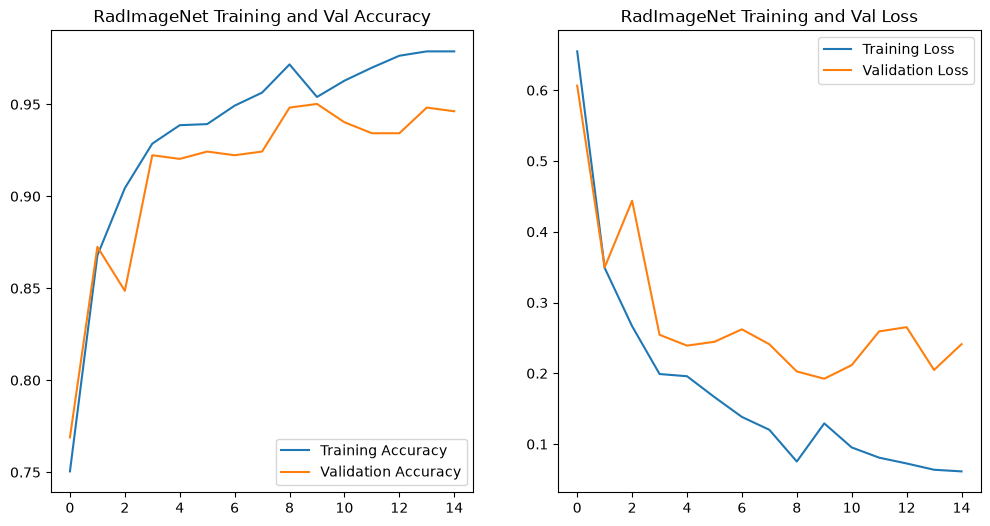

In [5]:
# --- Step 5: Compile and Initial Training (RadImageNet) ---
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt

# 1. Compile the RadImageNet model
rad_model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

# 2. Setup Callbacks
early_stopping_rad = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
model_checkpoint_rad = ModelCheckpoint('saved_models/radimagenet_model.h5', monitor='val_loss', save_best_only=True)

# 3. Train the model (Feature Extraction phase)
print("Starting initial training on RadImageNet features...")
EPOCHS = 20
history_rad = rad_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=[early_stopping_rad, model_checkpoint_rad]
)
print("Initial Training completed!")

# 4. Visualize the Training History
acc = history_rad.history['accuracy']
val_acc = history_rad.history['val_accuracy']
loss = history_rad.history['loss']
val_loss = history_rad.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('RadImageNet Training and Val Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('RadImageNet Training and Val Loss')
plt.show()

Unfreezing the top layers of the base model...


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 2048)           │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │         8,196 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,595,908 (90.01 MB)

 Trainable params: 16,958,724 (64.69 MB)

 Non-trainable params: 6,637,184 (25.32 MB)


Starting Fine-Tuning...
Epoch 15/35
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 971ms/step - accuracy: 0.9699 - loss: 0.0886

53/53 ━━━━━━━━━━━━━━━━━━━━ 68s 1s/step - accuracy: 0.9699 - loss: 0.0886 - val_accuracy: 0.9502 - val_loss: 0.1920
Epoch 16/35
53/53 ━━━━━━━━━━━━━━━━━━━━ 59s 1s/step - accuracy: 0.9735 - loss: 0.0824 - val_accuracy: 0.9442 - val_loss: 0.1963
Epoch 17/35
53/53 ━━━━━━━━━━━━━━━━━━━━ 60s 1s/step - accuracy: 0.9735 - loss: 0.0827 - val_accuracy: 0.9402 - val_loss: 0.2000
Epoch 18/35
53/53 ━━━━━━━━━━━━━━━━━━━━ 65s 1s/step - accuracy: 0.9735 - loss: 0.0793 - val_accuracy: 0.9422 - val_loss: 0.2019
Epoch 19/35
53/53 ━━━━━━━━━━━━━━━━━━━━ 60s 1s/step - accuracy: 0.9752 - loss: 0.0685 - val_accuracy: 0.9382 - val_loss: 0.2046
Epoch 20/35
53/53 ━━━━━━━━━━━━━━━━━━━━ 62s 1s/step - accuracy: 0.9829 - loss: 0.0579 - val_accuracy: 0.9402 - val_loss: 0.2064
Fine-Tuning completed!


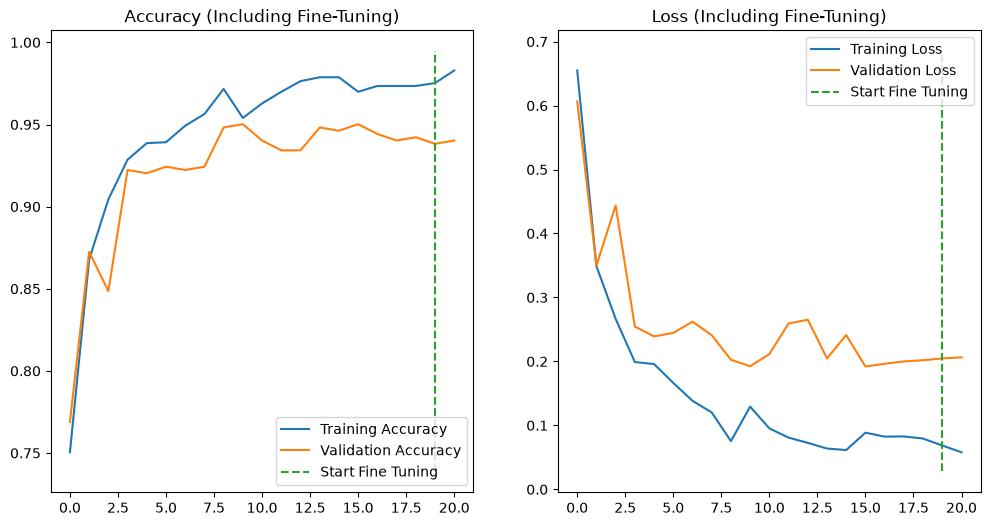

In [6]:
# --- Step 6: Fine-Tuning the RadImageNet Model ---

print("Unfreezing the top layers of the base model...")
# 1. Unfreeze the base model
base_model_rad.trainable = True

# We freeze the bottom layers and only fine-tune the top 50 layers.
# This protects the basic edge-detection features while adapting the complex features to our specific tumors.
for layer in base_model_rad.layers[:-50]:
    layer.trainable = False

# 2. Recompile the model with a VERY LOW learning rate!
# The standard learning rate is 0.001. We use 0.00001 (1e-5) for fine-tuning.
# If we use a normal learning rate, we will destroy the pre-trained weights.
rad_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

rad_model.summary()

# 3. Setup Callbacks for Fine-Tuning
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
early_stopping_ft = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
model_checkpoint_ft = ModelCheckpoint('saved_models/radimagenet_finetuned.h5', monitor='val_loss', save_best_only=True)

# 4. Fine-Tune the Model
print("\nStarting Fine-Tuning...")
FINE_TUNE_EPOCHS = 15
total_epochs = EPOCHS + FINE_TUNE_EPOCHS

# We resume training precisely from where the initial training left off
history_ft = rad_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=total_epochs,
    initial_epoch=history_rad.epoch[-1], # Starts at epoch 20
    callbacks=[early_stopping_ft, model_checkpoint_ft]
)
print("Fine-Tuning completed!")

# 5. Visualize the Full Training History (Initial + Fine-Tuning)
acc += history_ft.history['accuracy']
val_acc += history_ft.history['val_accuracy']
loss += history_ft.history['loss']
val_loss += history_ft.history['val_loss']

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.plot([EPOCHS-1,EPOCHS-1], plt.ylim(), label='Start Fine Tuning', linestyle='--')
plt.legend(loc='lower right')
plt.title('Accuracy (Including Fine-Tuning)')

plt.subplot(1, 2, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.plot([EPOCHS-1,EPOCHS-1], plt.ylim(), label='Start Fine Tuning', linestyle='--')
plt.legend(loc='upper right')
plt.title('Loss (Including Fine-Tuning)')
plt.show()

Loading the best RadImageNet model weights...



Evaluating on completely unseen Test Dataset:
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 541ms/step - accuracy: 0.9512 - loss: 0.1432

Final RadImageNet Test Accuracy: 95.12%

Generating predictions for Confusion Matrix...


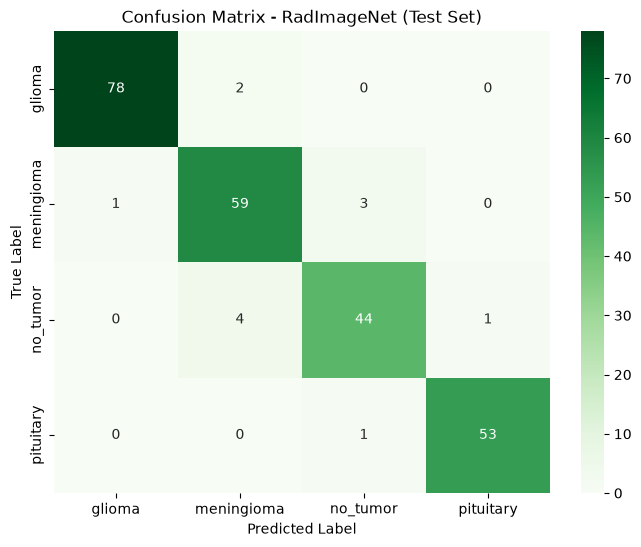


Classification Report:
              precision    recall  f1-score   support

      glioma       0.99      0.97      0.98        80
  meningioma       0.91      0.94      0.92        63
    no_tumor       0.92      0.90      0.91        49
   pituitary       0.98      0.98      0.98        54

    accuracy                           0.95       246
   macro avg       0.95      0.95      0.95       246
weighted avg       0.95      0.95      0.95       246



In [7]:
# --- Step 7: Final Evaluation & Comparison ---
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

print("Loading the best RadImageNet model weights...")
# We load the finetuned model (which automatically reverted to the 95% accuracy weights!)
best_rad_model = tf.keras.models.load_model('saved_models/radimagenet_finetuned.h5')

print("\nEvaluating on completely unseen Test Dataset:")
test_loss, test_acc = best_rad_model.evaluate(test_dataset)
print(f"\nFinal RadImageNet Test Accuracy: {test_acc*100:.2f}%")

print("\nGenerating predictions for Confusion Matrix...")
y_true = []
y_pred_probs = []

# Extract true labels and get model predictions
for images, labels in test_dataset:
    y_true.extend(labels.numpy())
    preds = best_rad_model.predict(images, verbose=0)
    y_pred_probs.extend(preds)

y_true = np.array(y_true)
y_pred = np.argmax(y_pred_probs, axis=1)

# Plot Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
# Using 'Greens' color map to distinguish it from the Custom CNN's blue matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - RadImageNet (Test Set)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Print Classification Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))